In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import random
import time
from intervention_models import *
from spreading_models import *
from tqdm import tqdm
import copy
import heapq
from scipy.linalg import expm
import collections
import sys
import pickle
import glob
import scipy
import seaborn as sns
import matplotlib
import warnings

In [2]:
class RtLog:
    import traceback

    def __init__(self, outpath, horizon, check_if_exists=True, min_samples_necc=10):
        self.outpath = outpath
        horizon = int(horizon + 0.5)
        self.rt_dict_count = {d: 0 for d in range(horizon + 1)}
        self.rt_dict_sum = {d: 0.0 for d in range(horizon + 1)}
        self.horizon = horizon
        assert (min_samples_necc > 0)
        self.min_samples_necc = min_samples_necc

        if check_if_exists and os.path.exists(self.outpath + '.csv'):
            df = pd.read_csv(self.outpath + '.csv')
            self.write_output(list(df['Time']), list(
                df['NumInfected']), list(df['SampleNum']))
            print('Rt_file exists, write plot.')

    def add_data_point(self, time, num_infected):
        d = int(time + 0.999999)  # this is a hack to only have inits for zero
        if d > self.horizon:
            return
        self.rt_dict_count[d] += 1
        self.rt_dict_sum[d] += num_infected

    def summarize(self):

        x = sorted(list(self.rt_dict_count.keys()))
        x = [d for d in x if self.rt_dict_count[d] >= 1]
        y = [self.rt_dict_sum[d] / self.rt_dict_count[d]
             for d in x if self.rt_dict_count[d] >= 1]
        z = [self.rt_dict_count[d] for d in x if self.rt_dict_count[d] >= 1]

        max_sample = min(100, np.max(z))  # 100 samples is enough
        max_sample = max(20, max_sample)  # but should be more tha 20
        # alphas = [max(0.05,z_i/max_sample) for z_i in z]
        # alphas = [min(0.9, alpha_i) for alpha_i in alphas]
        self.write_output(x, y, z)

    def write_output(self, x, y, z):
        x_filter = [x_i for i, x_i in enumerate(
            x) if z[i] >= self.min_samples_necc]
        y_filter = [y_i for i, y_i in enumerate(
            y) if z[i] >= self.min_samples_necc]
        # z_filter = [z_i for z_i in z if z_i >= self.min_samples_necc]

        plt.clf()
        plt.xticks(fontsize=24)
        plt.yticks(fontsize=24)
        plt.locator_params(axis='y', nbins=6)
        plt.locator_params(axis='x', nbins=6)
        plt.scatter([x_filter[0]], [y_filter[0]], alpha=0.8, facecolor=(76 / 255, 114 / 255, 176 / 255),
                    edgecolors=(76 / 255, 114 / 255, 176 / 255), linewidths=0, marker='s', s=200)
        plt.scatter(x_filter[1::], y_filter[1::], alpha=0.8, facecolor='None',
                    edgecolors=(203 / 255, 1 / 255, 98 / 255),
                    linewidths=2)
        (plt.gca()).tick_params(axis='both', which='both', length=0)
        plt.xlabel('Time of Exposure ', fontsize=30)
        plt.ylabel(r'$R_t$', fontsize=30)

        plt.savefig(self.outpath, bbox_inches="tight")
        df = pd.DataFrame({'Time': x, 'NumInfected': y, 'SampleNum': z})
        df.to_csv(self.outpath + '.csv')
        return x, y



In [3]:
#
# Simulation Code
#

def get_critical_value(contact_network):
    A = nx.adj_matrix(contact_network)
    A = A.toarray()
    E = scipy.linalg.eigvals(A)
    E = sorted(list(E))
    l = E[-1].real
    beta = 1.0 / l
    return beta

def plot_rt_dict(rt_dict, G, rt_log):
    for n in G.nodes():
        rt_log.add_data_point(rt_dict[(n, 'start')], rt_dict[(n, 'infected')])

In [4]:
def plot_degree_distribution(G, outpath):
    degrees = [G.degree(n) for n in G.nodes()]
    x_values = range(np.max(degrees) + 1)
    y_values = [degrees.count(d) for d in x_values if degrees.count(d) > 0]
    x_values = [d for d in x_values if degrees.count(d) > 0]
    plt.clf()
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    plt.locator_params(axis='y', nbins=6)
    plt.locator_params(axis='x', nbins=6)
    plt.scatter(x_values, y_values, alpha=0.8, facecolor='None', edgecolors=(76 / 255, 114 / 255, 176 / 255),
                linewidths=2)
    plt.scatter([0], [0], alpha=0)
    (plt.gca()).tick_params(axis='both', which='both', length=0)
    plt.xlabel('Degree', fontsize=20)
    plt.ylabel('Number of Nodes', fontsize=20)

    plt.savefig(outpath.replace('.gml', 'degrees.pdf'), bbox_inches="tight")
    df = pd.DataFrame({'Time': x_values, 'NumInfected': y_values})
    df.to_csv(outpath.replace('.gml', 'degrees.csv'))

In [5]:
def simulation_run(G, model, time_point_samples, max_steps=None, node_wise_matrix=None,
                   interventions=None, rt_log=None):
    rt_dict = dict()
    global_clock = 0.0
    step_i = 0
    time_point_sample_index = 0
    event_queue = []  # init
    x_values = list(time_point_samples)
    y_values = {state: list() for state in model.states()}  # record of trajectory
    node_counter = {state: len([n for n in G.nodes() if G.nodes[n]['state'] == state]) for state in model.states()}
    if node_wise_matrix is not None:
        assert (node_wise_matrix.shape == (G.number_of_nodes(), len(x_values)))
    if interventions is not None and (not hasattr(interventions, '__iter__')):
        interventions = [interventions]

    if rt_dict is not None:
        for node_i in G.nodes():
            # infected zero and active at horizon
            rt_dict[(node_i, 'infected')] = 0
            rt_dict[(node_i, 'start')] = time_point_samples[-1] + \
                10  # infected zero and active at horizon

    # init event_id
    for node_i in G.nodes():
        G.nodes[node_i]['event_id'] = 0
        if rt_dict is not None and G.nodes[node_i]['state'] != 'S':
            rt_dict[(node_i, 'start')] = 0.0

        # init queue
    for node_i in G.nodes():
        e = model.next_event(G, node_i, global_clock, init_event=True)
        heapq.heappush(event_queue, e)

    while len(x_values) > 0:

        if max_steps is not None and step_i >= max_steps:
            print('Abort simulation')
            return y_values

        # pop next event
        current_event = heapq.heappop(event_queue)
        new_time, event_type, event_content = current_event

        # check event type
        assert (event_type in ['model', 'intervention'])
        global_clock = new_time
        if event_type == 'model':
            src_node, new_state, event_id = event_content
        else:
            intervention = event_content[0]
            intervention.perform_intervention(G, model, current_event, global_clock, time_point_samples, event_queue,
                                              node_counter)

        # store
        while len(x_values) > 0 and global_clock >= x_values[0]:
            for state in model.states():
                y_values[state].append(node_counter[state])
            if node_wise_matrix is not None:
                for n in G.nodes():
                    node_wise_matrix[n, time_point_sample_index] = model.states().index(
                        G.nodes[n]['state'])
            x_values = x_values[1:]
            time_point_sample_index += 1
        if len(x_values) == 0:
            #plot_rt_dict(rt_dict, G, rt_log)
            return y_values

        # continue if intervention
        if event_type == 'intervention':
            continue

        old_state = G.nodes[src_node]['state']

        # reject
        if G.nodes[src_node]['event_id'] != event_id:
            e = model.next_event(G, src_node, global_clock)
            heapq.heappush(event_queue, e)
            continue
        # this also signals the model that the event is actually happening
        if model.reject(G, src_node, old_state, new_state, global_clock):
            e = model.next_event(G, src_node, global_clock)
            heapq.heappush(event_queue, e)
            continue

        # apply event
        G.nodes[src_node]['last_changed'] = global_clock
        node_counter[old_state] -= 1
        G.nodes[src_node]['state'] = new_state
        node_counter[new_state] += 1

        if rt_dict is not None and new_state in ['E']:
            rt_dict[(src_node, 'start')] = global_clock
            car_neighbors = [n for n in G.neighbors(
                src_node) if G.nodes[n]['state'] == 'C']
            inf_neighbors = [n for n in G.neighbors(
                src_node) if G.nodes[n]['state'] == 'I']
            z = len(car_neighbors) + len(inf_neighbors) * \
                0.2  # hard coded gamma!!!
            assert (len(car_neighbors) + 0.2 * len(inf_neighbors) == z)
            for n_c in car_neighbors:
                rt_dict[(n_c, 'infected')] += 1.0 / z
            for n_i in inf_neighbors:
                rt_dict[(n_i, 'infected')] += 0.2 / z

        step_i += 1

        # create new event
        e = model.next_event(G, src_node, global_clock)
        heapq.heappush(event_queue, e)
        for neighbor in G.neighbors(src_node):
            e_neig = model.next_event(G, neighbor, global_clock)
            heapq.heappush(event_queue, e_neig)

        # perform interventions
        if interventions is not None:
            for intervention in interventions:
                intervention.perform_intervention(G, model, current_event, global_clock, time_point_samples,
                                                  event_queue, node_counter)

    #plot_rt_dict(rt_dict, G, rt_log)
    return y_values

In [6]:
def simulate(G, model, time_point_samples, num_runs=None, outpath='output/output.pdf', max_steps=None,
             node_wise_matrix=None, interventions=None, init_args=dict(), check_if_already_run=False,
             extensive_plotting=False, alter=None, rt_log=None, ssa=False):
    if num_runs is None:
        num_runs = RUN_NUM
    G = nx.convert_node_labels_to_integers(G)
    #write_graph(G, outpath.replace('.pdf', '') + 'graph.gml')

    # already computed
    if check_if_already_run and os.path.exists(outpath + '.csv'):
        print('path already exits, read file: ', outpath, '.csv')
        df = pd.read_csv(outpath + '.csv')
        df_worstcase = lineplot(df, model, time_point_samples, outpath)
        return df, df_worstcase

    pbar = tqdm(total=num_runs)
    pbar.set_description('Simulations')
    infection_rate_original = model.infection_rate

    # create data frame to store values
    run_id_column = list()
    time_point_column = list()
    state_column = list()
    fraction_column = list()

    for run_i in range(num_runs):
        if alter is not None:
            # mod_value = random.random()*random_alter - (random_alter/2) #TODO put in model
            model.infection_rate = infection_rate_original
            model.infection_rate += alter
        # init
        G_run_i = copy.deepcopy(G)  # to not overwrite
        init_node_state = model.get_init_labeling(G, **init_args)
        for node in G_run_i.nodes():
            G_run_i.nodes[node]['state'] = init_node_state[node]
            G_run_i.nodes[node]['last_changed'] = 0.0

        if ssa:
            node_state_counts = model.ssa(
                G_run_i, time_point_samples, rt_log=rt_log)
        else:
            node_state_counts = simulation_run(G_run_i, model, time_point_samples, max_steps=max_steps,
                                               node_wise_matrix=node_wise_matrix, interventions=interventions,
                                               rt_log=rt_log)

        try:
            node_state_counts = model.aggregate(node_state_counts)
        except Exception as e:
            pass
        pbar.update(1)
        for x_i, time_point in enumerate(time_point_samples):
            for node_state, fractions in node_state_counts.items():
                run_id_column.append(run_i)
                time_point_column.append(time_point)
                state_column.append(node_state)
                fraction_column.append(
                    node_state_counts[node_state][x_i] / G.number_of_nodes())
    pbar.close()

    df = pd.DataFrame(
        {'run_id': run_id_column, 'Time': time_point_column, 'State': state_column, 'Fraction': fraction_column})
    df.to_csv(outpath + '.csv')
    if rt_log is not None:
        rt_log.summarize()
    df_worstcase = lineplot(df, model, time_point_samples,
                            outpath, extensive_plotting=extensive_plotting)
    return df, df_worstcase


In [7]:
def worst_case_filter(df, percentage=0.05, state='I'):
    run_id_value = {i: 0.0 for i in set(df['run_id'])}

    for index, row in df.iterrows():
        if row['State'] == state:
            id = row['run_id']
            run_id_value[id] = max(run_id_value[id], row['Fraction'])

    max_of_run = list(run_id_value.items())
    max_of_run = sorted(max_of_run, key=lambda x: -x[1])
    worst_case_index = int(len(max_of_run) * percentage)
    max_of_run = max_of_run[:worst_case_index]
    max_index_set = set([i for i, v in max_of_run])
    df_filtered = df[df.apply(
        lambda line: line['run_id'] in max_index_set, axis=1)]
    return df_filtered


def worst_case_estimator(values, percentage=0.1):
    values = sorted(list(values), reverse=True)
    worst_case_index = int(len(values) * percentage)
    values = values[:worst_case_index]
    return np.mean(values)


def lineplot(df, model, time_point_samples, outpath, extensive_plotting=False):
    plt.clf()
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    plt.locator_params(axis='y', nbins=6)
    plt.locator_params(axis='x', nbins=6)

    palette = None
    try:
        palette = model.colors()
    except Exception as e:
        pass
    sns.lineplot(x="Time", y="Fraction", hue='State',
                 data=df, ci=95, palette=palette)
    plt.ylim([0, 1])
    plt.xlim([0, time_point_samples[-1]])
    plt.xlabel('Time', fontsize=30)
    plt.ylabel('Prevalence', fontsize=30)
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", prop={'size': 17})
    (plt.gca()).tick_params(axis='both', which='both', length=0)
    plt.savefig(outpath.replace('.pdf', '_full.pdf'), bbox_inches="tight")
    # plt.show(block=False)

    # worst case
    plt.clf()
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    plt.locator_params(axis='y', nbins=6)
    plt.locator_params(axis='x', nbins=6)
    plt.xlabel('Time', fontsize=30)
    plt.ylabel('Prevalence', fontsize=30)

    df_worstcase = worst_case_filter(df)
    df.to_csv(outpath.replace('.csv', '') + '_worstcase.csv')
    sns.lineplot(x="Time", y="Fraction", hue='State',
                 data=df_worstcase, ci=95, palette=palette)
    # sns.lineplot(x="Time", y="Fraction", hue='State', data=df, ci=95, palette=palette, alpha=0.07)
    plt.ylim([0, 1])
    plt.xlim([0, time_point_samples[-1]])
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", prop={'size': 17})
    (plt.gca()).tick_params(axis='both', which='both', length=0)
    plt.savefig(outpath.replace('.pdf', '_worstcase.pdf'), bbox_inches="tight")

    plt.clf()
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    plt.locator_params(axis='y', nbins=6)
    plt.locator_params(axis='x', nbins=6)
    plt.xlabel('Time', fontsize=30)
    plt.ylabel('Prevalence', fontsize=30)
    sns.lineplot(x="Time", y="Fraction", hue='State', data=df_worstcase, ci=None, palette=palette, ls='--', alpha=0.5,
                 legend=False)
    sns.lineplot(x="Time", y="Fraction", hue='State',
                 data=df, ci=95, palette=palette)
    plt.ylim([0, 1])
    plt.xlim([0, time_point_samples[-1]])
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", prop={'size': 17})
    (plt.gca()).tick_params(axis='both', which='both', length=0)
    plt.savefig(outpath.replace('.pdf', '_worstcase2.pdf'),
                bbox_inches="tight")

    return df_worstcase


def final_mean_in_state(df, state='R'):
    last_time_point = np.max(df['Time'])
    df = df[df.apply(lambda line: line['Time'] ==
                     last_time_point and line['State'] == state, axis=1)]
    if len(df['Fraction']) == 0:
        return 0.0
    return np.mean(df['Fraction'])


def final_mean(df, model):
    return {state: final_mean_in_state(df, state=state) for state in model.states()}


def solve_ode(model, time_point_samples, outpath='output_gif/output_ode.pdf', extensive_plotting=False):
    plt.clf()
    from scipy.integrate import odeint
    init = model.ode_init()
    f = model.ode_func
    sol = odeint(f, init, time_point_samples)
    # try:
    sol = model.aggregate_ode(sol)
    # except:
    #    pass
    np.savetxt(outpath + '.csv', sol)
    traj_map = dict()
    for state_i, state in enumerate(model.ode_states()):
        sol_i = sol[:, state_i]
        try:
            c = model.colors()[state]
        except Exception as e:
            c = None
        traj_map[state] = sol_i
        plt.plot(time_point_samples, sol_i, label=state, c=c, alpha=0.8, lw=2)
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
    plt.ylim([0, 1])
    plt.xlim([0, time_point_samples[-1]])
    plt.xlabel('Time', fontsize=30)
    plt.ylabel('Prevalence', fontsize=30)
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", prop={'size': 17})
    (plt.gca()).tick_params(axis='both', which='both', length=0)
    if extensive_plotting:
        pass
        # plt.plot(time_point_samples, exp_baseline(time_point_samples), alpha=0.5, c='black', lw=3, label='exp', ls=':')
    plt.savefig(outpath, bbox_inches="tight")
    # plt.show(block=False)
    if extensive_plotting:
        plt.ylim([0.0001, 1])
        (plt.gca()).set_yscale('log')
        plt.savefig(outpath + 'log.pdf', bbox_inches="tight")
    print('final values of ODE: ', {model.states()[
          i]: sol[-1, i] for i in range(len(model.states()))})

    final_state = {s: v[-1] for s, v in traj_map.items()}
    max_y = np.max(traj_map['I_total'])
    max_x = list(traj_map['I_total']).index(max_y)

    return sol, max_x, max_y, final_state


def mean_at_day(df, state='I_total', dayfrac=0.1):
    df = df[df.apply(lambda line: state in line['State'], axis=1)]
    xy_map = dict()

    for index, row in df.iterrows():
        value = row['Fraction']
        t = row['Time']
        if t not in xy_map:
            xy_map[t] = list()
        xy_map[t].append(value)
    xy_map_mean = {x: np.mean(y) for x, y in xy_map.items()}

    xy_map_mean = sorted(list(xy_map_mean.items()), key=lambda x: x[0])

    t_i = int(len(xy_map_mean) * dayfrac)
    return xy_map_mean[t_i][1]


def output_analysis(df, state='I'):
    df = df[df.apply(lambda line: state == line['State'], axis=1)]
    xy_map = dict()

    for index, row in df.iterrows():
        value = row['Fraction']
        t = row['Time']
        if t not in xy_map:
            xy_map[t] = list()
        xy_map[t].append(value)

    xy_map_mean = {x: np.mean(y) for x, y in xy_map.items()}

    xy_map_list = list(xy_map_mean.items())
    xy_values = sorted(xy_map_list, key=lambda xy: xy[1])
    xy_max = xy_values[-1]
    print('xy max', xy_max)

    return xy_max[0], xy_max[1]

In [10]:
G = nx.read_gexf('../grafo_cidades_aeroportos.gexf')

Simulations: 100%|██████████| 20/20 [01:04<00:00,  3.22s/it]


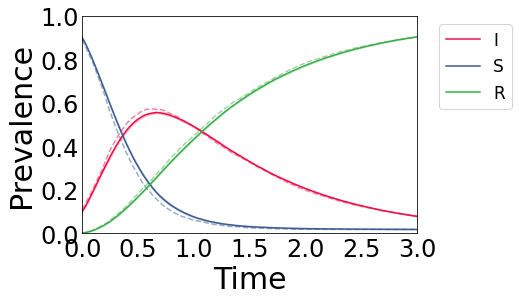

In [51]:
time_point_samples = np.linspace(0, 3, 100)
SIR_model = SIRmodel(infection_rate=1.3)
df = simulate(G, SIR_model, time_point_samples, outpath='output/output_SIR',
                  num_runs=20)

Simulations: 100%|██████████| 20/20 [00:10<00:00,  1.90it/s]


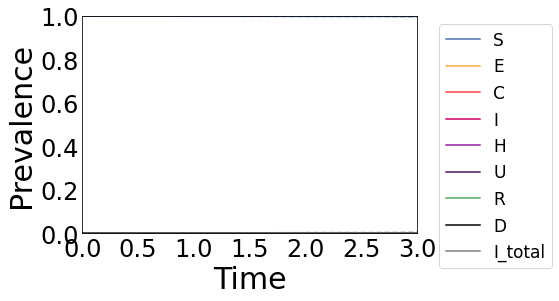

In [56]:
time_point_samples = np.linspace(0, 3, 100)
coronaHelmholz_model = CoronaHelmholz(G)
df = simulate(G, coronaHelmholz_model, time_point_samples, outpath='output/output_coronaHelmholz',
                  num_runs=20)


Simulations:   0%|          | 0/20 [00:00<?, ?it/s]/Users/ana/Desktop/gcavali-repo/spreading_models.py:668: RuntimeWarning: divide by zero encountered in double_scalars
  state_firetime = [(s, -np.log(random.random()) / r) for s, r in state_rate]
Simulations: 100%|██████████| 20/20 [02:45<00:00,  8.28s/it]


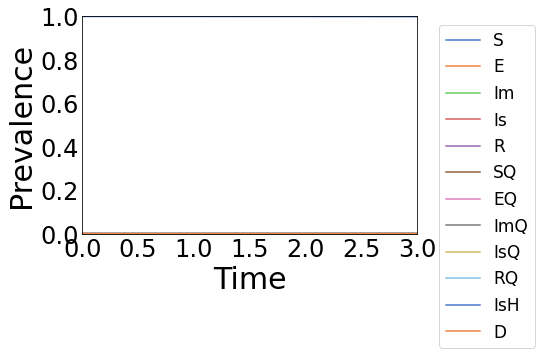

In [57]:
time_point_samples = np.linspace(0, 3, 100)
coronaBase_model = CoronaBase()
df = simulate(G, coronaBase_model, time_point_samples, outpath='output/output_coronaBase',
                  num_runs=20)
